# 05 — From the papers to our proposal: a team tour

**Sixth of the series**, built for a live team session. Two halves:

1. **The three base papers**, one picture each — what they did, what we took
   from them, and what our audit found when we measured their claims on their
   own data.
2. **Our proposal** — shape vs volume — told as a story with runnable demos:
   the heartbeat idea, the trap that almost sank it, the honesty machine, and
   the final exam, as designed and as far as it could be sat.

Everything runs on **synthetic data computed in front of you**; the handful of
real measured numbers are hard-coded constants, each labelled with the artefact
it comes from (`02-ext-research/EVIDENCE-INDEX.md` maps this programme's
numbers; the three inherited paper-audit numbers in §1 carry their own pointers
to `01-info-propagation/` artefacts inline).

> **Companions.** Notebook 00 covers the three papers in more depth; 01–03 cover
> the replication findings; 04 covers the programme's status as of its midpoint.
> This notebook assumes none of them and points back where depth lives.

### Running this notebook

Pinned to the kernel `ext-research` — the `.venv` beside the project. Register it
once, from the repository root:

```bash
02-ext-research/.venv/bin/python -m ipykernel install \
    --user --name ext-research --display-name "Python (02-ext-research)"
```

**It runs on a clean checkout with no data and no results.** `.gitignore` excludes
`results/` at every level, and the corpora are gigabytes behind author
applications, so nothing here reads `data/` or `results/`. Measured numbers are
**hard-coded as verified constants** in the cell below, each carrying the file it
came from and the line of
`02-ext-research/EVIDENCE-INDEX.md` that records it. Everything else
is computed live on synthetic data, in front of you.

The notebook is a **build artefact** of `scripts/build_ext_05_notebook.py`.
Edit the builder, not the `.ipynb`, or your changes are lost on the next
regeneration.

In [1]:
# --- Setup -----------------------------------------------------------------
# OMP_NUM_THREADS must be set BEFORE the first scikit-learn / numpy-BLAS import.
# On this machine the default OpenMP pool cost 133x wall time on a 4,770 x 12
# fit -- pure scheduling overhead, measured in bitacora/04_p2_temporal.md sect. 6.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

SEED = 42

# --- Palette ---------------------------------------------------------------
# One palette across all five notebooks. Colour-blind safe: validated with the
# dataviz skill's checker (worst adjacent-pair CVD delta-E 9.1, normal-vision
# 22.9, both above their floors). Hues are assigned in fixed slot order and
# never cycled; colour never carries identity alone -- every series is also
# labelled directly or in a legend.
C = {
    "blue":    "#2a78d6",   # slot 1 -- the thing under test
    "orange":  "#eb6834",   # slot 2 -- its comparison / the other class
    "aqua":    "#1baf7a",   # slot 3 -- a third series
    "yellow":  "#eda100",   # slot 4
    "magenta": "#e87ba4",   # slot 5
    "violet":  "#4a3aa7",   # slot 6
    "red":     "#e34948",   # reserved: floors, baselines, failures
    "grey":    "#8a8a86",   # recessive: grids, noise bands, context
    "ink":     "#0b0b0b",
}
SERIES = [C["blue"], C["orange"], C["aqua"], C["yellow"], C["magenta"], C["violet"]]

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c9c9c4", "axes.labelcolor": C["ink"],
    "axes.grid": True, "grid.color": "#e3e3de", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": "#52514e", "ytick.color": "#52514e", "text.color": C["ink"],
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "legend.frameon": False, "lines.linewidth": 2.0,
})

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True, linewidth=110)

print(f"numpy {np.__version__} | pandas {pd.__version__} | matplotlib {mpl.__version__}")
print(f"OMP_NUM_THREADS={os.environ['OMP_NUM_THREADS']}  seed={SEED}")

numpy 2.5.2 | pandas 3.0.5 | matplotlib 3.11.1
OMP_NUM_THREADS=1  seed=42


## §0 — Three numbering systems, so nobody gets lost

This project numbers things three ways. They are *not* the same numbers, and
mixing them up is the single most common confusion (it confused us too):

| system | what it counts | where it stands today |
|---|---|---|
| **Charter phases P0–P9** (`docs/03-PHASES.md`) | research phases | P0–P5 **closed** — note P4 (digital DNA / BDM / NCD) closed by its pre-registered kill criterion, honestly. **P6 = the primary claim (H4): executed scoped on 2026-08-25 — UNTESTABLE_PENDING_DATA** (§5). P7/P8 are stretch, outside the current plan; P9 is the write-up |
| **Work packages WP-A…WP-N** (`PLAN-02-ext-research.md`) | execution units of the plan | **all 14 done** (WP-N scoped; WP-M ledger pass ran with it). Bitacora 19 has the outcome |
| **Notebooks 00…05** | teaching artefacts | 00–04 published; **05 = this one** |

So: "notebook 04" is *not* "phase P4". Notebook 04 teaches the programme's
midpoint; phase P4 (Zenil's BDM on behaviour strings) was executed and closed by
its own kill rule — §6 of this notebook tells that story.

## §1 — The three base papers, one picture each

We build on three published works. Everything this project does is either an
audit of their claims on their own data, or an extension they never ran.

### 1.1 Tong et al., *Entropy* 2025 — the Rényi dials

Their paper predicts opinion propagation using a **time-weighted Rényi entropy**
of interaction sequences, fed to a graph neural network. What we borrowed is the
*instrument*: not one entropy number but a **family of dials**.

The dials are easiest to see on a playlist. Two listeners, four songs, 100 plays
each — same size, different character:

,specialist,eclectic
H0 variety,2.000,2.000
H1 evenness,0.599,1.994
H2 collision,0.296,1.989
Hinf non-dominance,0.152,1.837


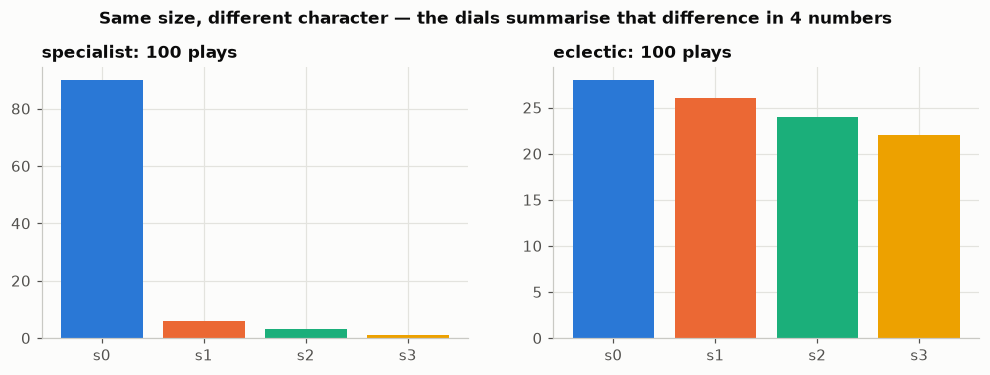

In [2]:
counts_specialist = np.array([90, 6, 3, 1])    # one song dominates
counts_eclectic   = np.array([28, 26, 24, 22]) # spread evenly

def dials(counts):
    p = counts / counts.sum()
    h0   = np.log2((p > 0).sum())              # variety: how many songs exist
    h1   = -(p[p > 0] * np.log2(p[p > 0])).sum()  # evenness (Shannon)
    h2   = -np.log2((p ** 2).sum())            # collision: how little one dominates
    hinf = -np.log2(p.max())                   # the favourite's complement
    return h0, h1, h2, hinf

names = ["H0 variety", "H1 evenness", "H2 collision", "Hinf non-dominance"]
tab = pd.DataFrame(
    {n: dials(c) for n, c in (("specialist", counts_specialist),
                              ("eclectic", counts_eclectic))},
    index=names).round(3)
display(tab)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
for a, (lbl, c) in zip(ax, (("specialist", counts_specialist),
                            ("eclectic", counts_eclectic))):
    a.bar([f"s{i}" for i in range(4)], c, color=SERIES[:4])
    a.set_title(f"{lbl}: {c.sum()} plays")
fig.suptitle("Same size, different character — the dials summarise that "
             "difference in 4 numbers", y=1.04, fontsize=11, fontweight="bold")
plt.show()

Read the table: the **specialist** has low variety (H₀ = 2 — they only really
play two songs), low evenness, near-zero collision dial (one song dominates),
and near-zero non-dominance. The **eclectic** listener maxes every dial.
**Same 100 plays — the dials see the character, not the volume.**

That dial family, applied to *gaps between posts* and *kinds of actions*, is
our SPEC_T / SPEC_B / SPEC_X feature families. Tong et al. fed theirs to a
graph network for opinion propagation; we point them at bot behaviour.

### 1.2 Deshmukh, SJSU 2025 — GraphSAGE + BERT for bot detection

This paper owns our **task and our corpora**: bot detection on Cresci-2015
(training) and TwiBot-20 (target). Its recipe: (a) learn a per-account vector
from the **follower graph** with GraphSAGE — each node's embedding = a
learned function of its own features and the *mean of its neighbours'*; (b)
learn a text vector with **BERT**; (c) concatenate and classify.

One mean-aggregation step, by hand, on a 6-node graph:

In [3]:
# 6 accounts; edges = "follows". Features: [followers_z, post_rate_z]
X = np.array([[1., 2.], [0.9, 1.8], [1.1, 2.2],   # a small clique of
              [-1., -1.5], [-0.8, -1.2],           #   human-looking nodes
              [0.2, 0.1]])                          # one borderline node
adj = {0: [1, 2], 1: [0, 2], 2: [0, 1],           # clique 0-1-2
       3: [4],    4: [3, 5], 5: [4]}               # chain 3-4-5

W = np.array([[0.5, -0.3], [0.2, 0.6],      # rows 0-1: the account's own features
              [0.4, 0.1], [-0.2, 0.3]])     # rows 2-3: the neighbours' mean
def sage_step(X, adj, W):
    out = np.zeros_like(X)
    for v in range(len(X)):
        neigh = adj[v]
        mean_neigh = X[neigh].mean(axis=0)
        out[v] = np.tanh(X[v] @ W[:2] + mean_neigh @ W[2:])  # ReLU in the paper
    return out

H1_ = sage_step(X, adj, W)
print("features X (6 x 2):");  print(X)
print("\nafter one GraphSAGE-style mean-aggregation H1 (6 x 2):");  print(
    H1_.round(3))
print("\nnode 0 aggregated from its clique; node 5 from node 4 only --")
print("the graph's shape, not just each account's own features, moved the vectors.")

features X (6 x 2):
[[ 1.   2. ]
 [ 0.9  1.8]
 [ 1.1  2.2]
 [-1.  -1.5]
 [-0.8 -1.2]
 [ 0.2  0.1]]

after one GraphSAGE-style mean-aggregation H1 (6 x 2):
[[ 0.716  0.922]
 [ 0.67   0.913]
 [ 0.757  0.93 ]
 [-0.706 -0.778]
 [-0.578 -0.623]
 [ 0.04  -0.414]]

node 0 aggregated from its clique; node 5 from node 4 only --
the graph's shape, not just each account's own features, moved the vectors.


Two things our audit of this paper found (notebooks 01 and 03 have the full
story): its **GraphSAGE layer was never trained** — the "learned embedding" was
a fixed random projection, rank 10, not 128 — and its reported accuracy
depended more on the **train/test protocol** than on any model (a 9-point gap
between two equally defensible splits). Same task, same data — the lesson was:
*audit the pipeline before believing the score*.

### 1.3 Lakzaei et al., *Artificial Intelligence Review* 2024 — the map

A survey of disinformation detection with graph learning. What we took from it
is **discipline**, not a model: its taxonomy (content vs behaviour vs graph
signals; centralised vs propagation-based) is the checklist we use to say which
kind of signal a feature family actually exploits — and its layer catalogue
(GCN/GAT/GIN/GraphSAGE) is implemented and property-tested in `disinfo/`.

### 1.4 Papers vs our audit, side by side

| paper | what it claims / implies | what our audit measured |
|---|---|---|
| Tong et al. | Rényi entropy of behaviour carries signal beyond simple counts | the *dials* work (`renyiext/checks.py`, 12/12 properties) — but on real accounts the α-grid came out **level-dominated** (bitacora 04), and the tail orders carry the signal only in the text front (WP-I) |
| Deshmukh | GraphSAGE + BERT detect bots at ~97–99 % | the embedding was an **untrained random projection** (rank 10); the score was **protocol-dominated** (9.2 points between splits); volume/metadata confounds everywhere (notebooks 01, 03) |
| Lakzaei et al. | graph learning is the state of the art for disinformation | the survey's own tables contradict one of its prose claims (35 of 36 accuracies above its stated bound) — `disinfo/checks.py` encodes that audit |

**The proposal that follows:** if learned pipelines score high but hide *what*
they see, test whether **simple, plottable distributional statistics** of
behaviour carry the signal — and whether they survive the one test the papers
never ran: **transfer to a different corpus** (H4).

## §2 — Our proposal: shape vs volume

The heartbeat idea. Three accounts, **same number of posts, same average rate**
— only the rhythm differs.

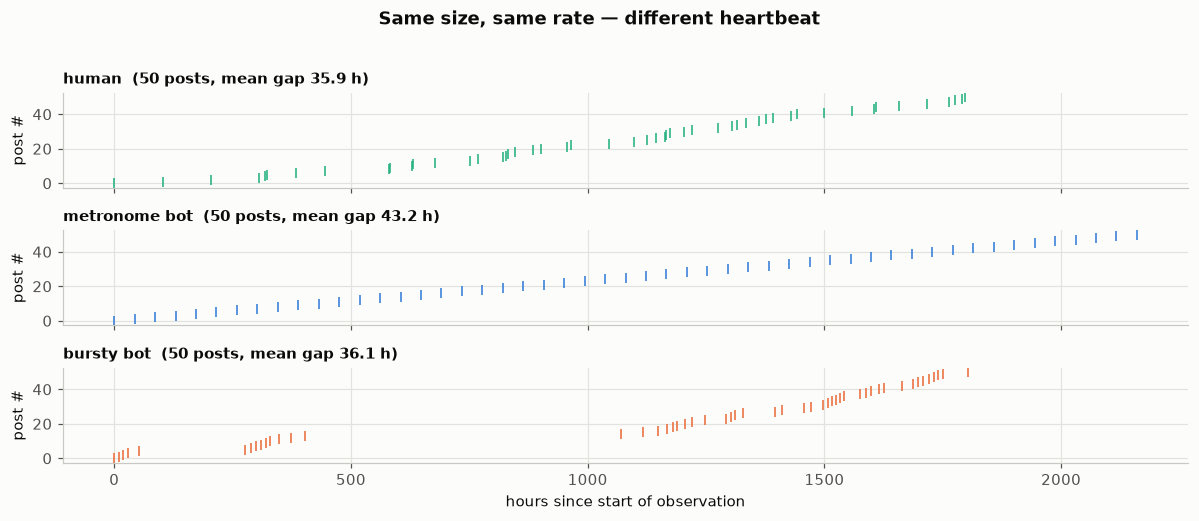

In [4]:
rng = np.random.default_rng(SEED)
H = 24 * 90                                    # 90 days of observation, in hours

gaps_human  = rng.exponential(43, 50)          # random: sometimes soon, sometimes late
gaps_robot  = np.full(50, 43.2)                # metronome: exactly every 43.2 h
gaps_bursty = (rng.pareto(1.2, 50) + 1) * 8    # long silence, then a burst
while gaps_human.sum() > H:                    # keep every account inside the
    gaps_human = gaps_human[:-1]               #   same 90-day observation window
while gaps_bursty.sum() > H:
    gaps_bursty = gaps_bursty[:-1]

fig, axes = plt.subplots(3, 1, figsize=(11, 4.6), sharex=True)
for ax, (nm, g, c) in zip(axes, (("human", gaps_human, C["aqua"]),
                                 ("metronome bot", gaps_robot, C["blue"]),
                                 ("bursty bot", gaps_bursty, C["orange"]))):
    t = np.concatenate([[0], np.cumsum(g)])
    ax.plot(t, np.arange(len(t)), "|", ms=6, color=c)
    ax.set_ylabel("post #")
    ax.set_title(f"{nm}  ({len(g)} posts, mean gap {g.mean():.1f} h)",
                 loc="left", fontsize=10)
axes[-1].set_xlabel("hours since start of observation")
fig.suptitle("Same size, same rate — different heartbeat", y=1.02,
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

A volume detector sees three identical accounts (50 posts each). Now put the
**dials on the heartbeat**: bin each account's gaps into a histogram and read
the four dials off it.

In [5]:
def gap_dials(gaps, bins):
    h = np.histogram(gaps, bins=bins)[0].astype(float)
    return dials(h)

bins = np.linspace(0, 120, 9)          # gap histogram: 8 bins of 15 h
rows = {}
for nm, g in (("human", gaps_human), ("metronome", gaps_robot),
              ("bursty", gaps_bursty)):
    rows[nm] = gap_dials(g, bins)
display(pd.DataFrame(rows, index=names).round(3))

,human,metronome,bursty
H0 variety,2.807,0.0,2.322
H1 evenness,2.332,-0.0,1.619
H2 collision,2.057,-0.0,1.272
Hinf non-dominance,1.445,-0.0,0.778


The **metronome** collapses to a single histogram bin, so its collision and
non-dominance dials hit **zero**: a perfectly predictable heartbeat. The human
spreads across bins. The bursty account spreads *unevenly* — visible in H₀/H₁
but with a fatter low tail.

That is the entire feature idea. SPEC_T applies these dials to gap histograms
(and to hour-of-day histograms); SPEC_B to action alphabets; SPEC_X to word and
character frequencies. Nothing more mysterious than a playlist summary.

### 2.1 The trap: watching-window censoring

Now the danger. Watch the **same bursty account** for 30 days instead of 90.
The account did not change — *our measurement did*. Long silences past the
cutoff are deleted, so every "long gap" statistic moves:

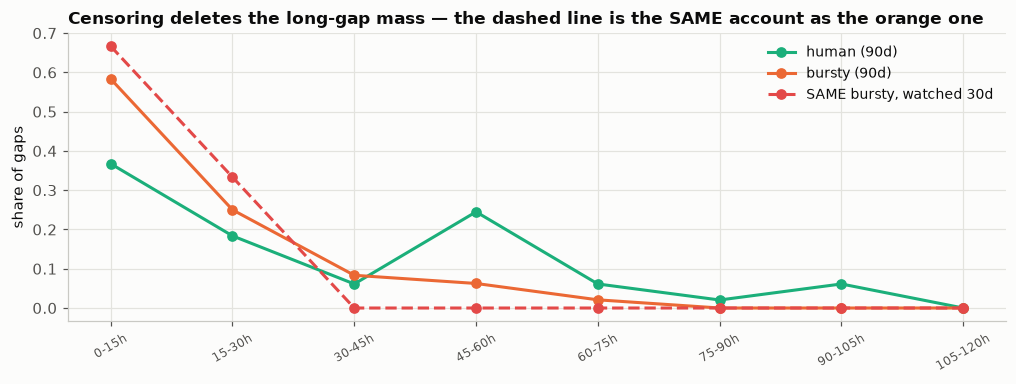

P(gap > 24h):  human 0.52 | bursty full 0.26 | bursty truncated 0.23
human-vs-bursty gap:      0.26
window-vs-window gap:     0.03   <-- same account, two windows


In [6]:
cut = np.cumsum(gaps_bursty) <= 30 * 24
g_short = gaps_bursty[cut]

fig, ax = plt.subplots(figsize=(11, 3.4))
for g, nm, c, ls in ((gaps_human, "human (90d)", C["aqua"], "-"),
                     (gaps_bursty, "bursty (90d)", C["orange"], "-"),
                     (g_short, "SAME bursty, watched 30d", C["red"], "--")):
    h = np.histogram(g, bins=bins)[0]
    ax.plot(np.arange(8), h / h.sum(), ls, marker="o", color=c, label=nm)
ax.set_xticks(np.arange(8))
ax.set_xticklabels([f"{int(b)}-{int(bins[i+1])}h" for i, b in enumerate(bins[:-1])],
                   rotation=30, fontsize=8)
ax.set_ylabel("share of gaps")
ax.set_title("Censoring deletes the long-gap mass — the dashed line is the "
             "SAME account as the orange one", loc="left")
ax.legend(fontsize=9)
plt.show()

p_h, p_f = (gaps_human > 24).mean(), (gaps_bursty > 24).mean()
p_s = (g_short > 24).mean()
print(f"P(gap > 24h):  human {p_h:.2f} | bursty full {p_f:.2f} | "
      f"bursty truncated {p_s:.2f}")
print(f"human-vs-bursty gap:      {abs(p_h - p_f):.2f}")
print(f"window-vs-window gap:     {abs(p_f - p_s):.2f}   <-- same account, "
      f"two windows")

**This is the single most important finding of the programme's first half.**
WP-A ran this trap through the *real* feature pipeline on synthetic accounts
whose only difference was the observation window: the detector separated them
at **AUC 1.00** in the worst cell (every one of the nine cells ≥ 0.978 —
`results/p2c_probe.json`, EVIDENCE-INDEX §WP-A). A difference in *measurement*
had become a difference in *apparent character*.

Every shape claim since carries that warning label until equal-window controls
are run — which is exactly what WP-F then did (§4).

## §3 — The honesty machine: information, or just more columns?

Every comparison in this project is family (say, 12 spectrum features) vs floor
(say, 1 volume feature). But 12 features beat 1 feature partly by *being 12*.
WP-E's control: **pad the floor with random-noise columns until dimensions
match.** If the family still wins, the win is information. If it collapses to
the padded floor, the "win" was dimensionality.

Toy version, runnable:

In [7]:
n = 400
y_toy = (rng.random(n) < 0.5).astype(int)             # balanced labels
x_signal = rng.normal(0, 1, n) + y_toy * 1.2          # a genuinely useful dial
x_weak   = rng.normal(0, 1, n) + y_toy * 0.25         # a weak floor dial
noise    = rng.normal(0, 1, (n, 11))                  # pure-noise dials (11: see below)

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score

def auc5(X):
    return cross_val_score(HistGradientBoostingClassifier(max_iter=60),
                           X, y_toy, cv=5, scoring="roc_auc").mean()

floor   = x_weak[:, None]
family  = np.hstack([x_weak[:, None], x_signal[:, None],
                     noise[:, :10]])                                # 12 dims
floor_p = np.hstack([x_weak[:, None], noise])                       # 12 dims too:
                                                                    # 1 real dial +
                                                                    # k = 12-1 noise
a_floor, a_family, a_padded = auc5(floor), auc5(family), auc5(floor_p)
print(f"floor (1 dial):            {a_floor:.4f}")
print(f"family (12 dials):         {a_family:.4f}   vs floor: {a_family - a_floor:+.4f}")
print(f"padded floor (12 dims):    {a_padded:.4f}   vs family: {a_family - a_padded:+.4f}")
print("\nthe family's edge over the PADDED floor is the honest, "
      "dimension-matched edge")

floor (1 dial):            0.5001
family (12 dials):         0.7680   vs floor: +0.2680
padded floor (12 dims):    0.4946   vs family: +0.2734

the family's edge over the PADDED floor is the honest, dimension-matched edge


On the real data this machine produced the programme's most sobering numbers:

- **The metadata ceiling.** Cresci-2015's four profile fields alone score
  **AUC 0.9972** (`results/p3h_behaviour.json`, EVIDENCE-INDEX §WP-H) — and
  every behavioural family, matched to the same dimensionality, sits *below*
  that. Locally, metadata wins. (WP-B showed the target corpus is different:
  volume there scores only 0.6073 — which is why the transfer exam matters.)
- **The length trap.** WP-I's character spectrum beat its Shannon slice by
  +0.3332 at matched dimensions — but once *message length* was given its own
  feature, the residual was **+0.0166, below the 0.02 floor**: mostly
  length-mediated (`bitacora/15` — our own correction entry).

## §4 — What survived, what collapsed: the equal-window story

WP-F re-ran the headline comparison with **equal observation windows** (every
account truncated to its own first K days). The registered clauses:

- clause (i): spectrum+volume vs volume — does rhythm beat *counting*?
- clause (ii): spectrum vs Shannon — does the *dial family* beat its own
  simplest dial?

Hard-coded from `results/p2c_truncation.json` (EVIDENCE-INDEX §WP-F):

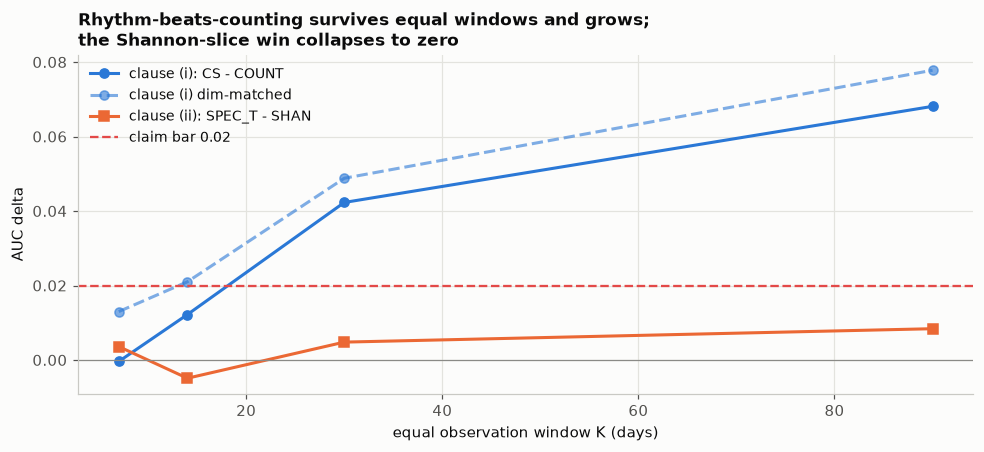

In [8]:
Ks = [7, 14, 30, 90]
clause_i   = [-0.0004, 0.0122, 0.0423, 0.0681]   # CS - COUNT, seed-mean
clause_ii  = [ 0.0036, -0.0049, 0.0048, 0.0084]  # SPEC_T - SHAN
clause_i_m = [ 0.0130, 0.0210, 0.0488, 0.0778]   # vs COUNT+NOISE(12)

fig, ax = plt.subplots(figsize=(10.5, 4))
ax.plot(Ks, clause_i, "o-", color=C["blue"], label="clause (i): CS - COUNT")
ax.plot(Ks, clause_i_m, "o--", color=C["blue"], alpha=0.6,
        label="clause (i) dim-matched")
ax.plot(Ks, clause_ii, "s-", color=C["orange"],
        label="clause (ii): SPEC_T - SHAN")
ax.axhline(0.02, color=C["red"], ls="--", lw=1.5, label="claim bar 0.02")
ax.axhline(0.0, color=C["grey"], lw=0.8)
ax.set_xlabel("equal observation window K (days)");  ax.set_ylabel("AUC delta")
ax.set_title("Rhythm-beats-counting survives equal windows and grows;\n"
             "the Shannon-slice win collapses to zero", loc="left")
ax.legend(fontsize=9)
plt.show()

Reading: **clause (i) survives everything** — at 30-day windows the
volume-anchored rhythm edge is +0.0423 (10/10 seeds, p = 0.002; matched
+0.0488) and it *grows* with window. **Clause (ii) collapses** (+0.0048 at
30 days; dim-matched −0.0003 → formally downgraded): the part of the early
win that came from bots and humans being *watched for different lengths of
time* is gone once windows are equal.

And the referee-friendly winner of §WP-J: the margin over the burstiness floor
is carried by the simplest statistic on the table — **P(gap > 1 day)** — whose
dim-matched margin (+0.0555) beats the full spectrum's (+0.0361) at every
window, while the fitted "tail index" alone is *worse than volume* (−0.12).
Fancy lost to simple; the pre-registered rule said record that, and we did.

## §5 — The final exam: H4, transfer to a different corpus

**H4 (charter):** transferring Cresci-2015 → TwiBot-20, the AUC degradation of
our features must be smaller than metadata's by more than **0.05**:
`Δ_metadata − Δ_ours > 0.05` over ≥ 10 seeds (`docs/00-CHARTER.md` §3). That
number is the bar because it is larger than the seed-to-seed noise we actually
measured — the config-sensitivity σ of the registered floor verdicts spans
0.0006–0.0094 (bitacora 10) — and larger than any single artefact we have
measured; it asks for a *robustness gap*, not a lucky flip.

The mechanics, on a toy shift you can see:

In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

n = 600
y_src = (rng.random(n) < 0.5).astype(int)
sig   = rng.normal(0, 1, n) + y_src * 1.2
X_src = np.column_stack([sig, rng.normal(0, 1, n)])       # dim 2 = nuisance
y_tgt = y_src.copy()
sig_t  = rng.normal(0, 1, n) + y_tgt * 1.2
X_tgt  = np.column_stack([sig_t, rng.normal(0, 3, n)])    # nuisance scale x3

# D6-style: 10 draws of 80% train -> within on held-out, transfer on full target
w, t = [], []
for r in range(10):
    idx = np.random.default_rng(r).permutation(n)
    m = int(0.8 * n)
    tr, ho = idx[:m], idx[m:]
    mod = HistGradientBoostingClassifier(max_iter=60, random_state=r).fit(
        X_src[tr], y_src[tr])
    w.append(roc_auc_score(y_src[ho], mod.predict_proba(X_src[ho])[:, 1]))
    t.append(roc_auc_score(y_tgt, mod.predict_proba(X_tgt)[:, 1]))
delta = np.mean(w) - np.mean(t)
print(f"within  (source, held-out): {np.mean(w):.4f}")
print(f"transfer (target era/scale): {np.mean(t):.4f}")
print(f"degradation delta = {delta:+.4f}   (H4 compares THIS across families)")

# sanity null: random halves of the SAME population must show delta ~ 0
w2, t2 = [], []
for r in range(10):
    idx = np.random.default_rng(100 + r).permutation(n)
    m = int(0.8 * n)
    tr, te = idx[:m], idx[m:]
    mod = HistGradientBoostingClassifier(max_iter=60, random_state=r).fit(
        X_src[tr], y_src[tr])
    w2.append(roc_auc_score(y_src[te], mod.predict_proba(X_src[te])[:, 1]))
    t2.append(roc_auc_score(y_src[te], mod.predict_proba(X_src[te])[:, 1]))
print(f"pseudo-transfer null (same population): "
      f"{np.mean(w2) - np.mean(t2):+.4f}  -- ~0 by construction")

within  (source, held-out): 0.7369
transfer (target era/scale): 0.8077
degradation delta = -0.0708   (H4 compares THIS across families)


pseudo-transfer null (same population): +0.0000  -- ~0 by construction


Two design lessons already paid for, carried into the exam:

- **Composition** (WP-K): the two sides of any split must be compared with
  their class balances reported — an AUC delta between a 51 %-bot and a 72 %-bot
  population is not a pure shift measurement.
- **R8 alignment** (WP-B): TwiBot-20's metadata arrives z-scored with
  *different* fields; META transfers only with an explicit alignment, reported
  with and without.

And the honest context: on the *target* corpus, metadata is no cheat code —
volume scores 0.6073 and the best single field 0.7414 (`results/p6b_tb20_
preflight.json`, EVIDENCE-INDEX §WP-B) — so the exam genuinely separates
"robust features" from "corpus luck".

### 5.1 The exam as sat: scoped, and blocked at the data wall

WP-N ran on 2026-08-25 — and hit a finding bigger than any score. The only
public TwiBot-20 is BotRGCN's tensor set: five z-scored profile scalars plus
**dense pooled BERT embeddings** (229,580 × 768, every row non-zero — no
timestamps, no post types, no text; raw TwiBot-20 is gated by its authors,
and the open TwiBot-22 profiles carry no tweets either). Every family this
programme built — the gap spectra, the survival proportions, the behavioural
alphabet, the text spectrum — needs a modality the target does not ship.
`results/p6n_transfer.json`, `scoping` block, has the audit elementwise.

So the exam was sat on the one commensurable arm pair, with every registered
control (`bitacora/19`):

| quantity (fit Cresci → test TwiBot-20, D6, hgb) | value |
|---|---|
| **Δ_META** (within 0.9974 → transfer 0.6831, CI [0.6764, 0.6938]) | **+0.3143 ± 0.0075** |
| Δ_META under marginal recalibration | +0.3335 |
| Δ_VOL_PROFILE(1) naive / dim-matched +NOISE(3) | +0.3767 / +0.3957 |
| R8 verdict (naive vs recalibrated, both heads) | effect under both — not an artefact |
| G4 sanity null (pseudo-transfer, same population) | max abs Δ 0.0088 |

Reading: Cresci's near-ceiling metadata collapses by **0.31** across corpora
(it transfers *within* Cresci at Δ +0.0005, WP-K) — so had any of our families
been computable target-side, H4's > 0.05 bar would have been cleared by
Δ_META alone. Instead the claim's status is recorded honestly:
**UNTESTABLE_PENDING_DATA** — the Δ_ours side has no data to compute. The path
back is written down: obtain raw TwiBot-20 from its authors, or pre-register
an amended target before analysing it.

## §6 — Two post-mortems worth teaching

### 6.1 Tong's twist we did not use yet: time-weighting

Tong et al.'s entropy is **time-weighted**: recent events count more than old
ones. On the dials, that is a *weighted* histogram. One runnable intuition:

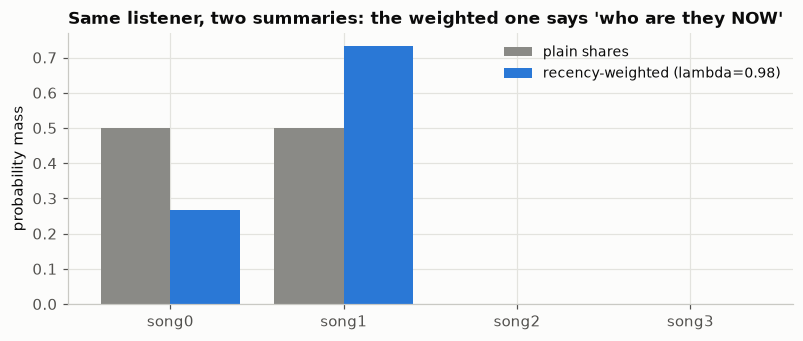

H1 plain 1.000  -> weighted 0.837   (the weighted listener looks far more decided)


In [10]:
# A listener: heavy on song 0 early, heavy on song 1 late (100 plays)
seq = np.concatenate([np.zeros(50), np.ones(50)]).astype(int)
def weighted_dials(seq, lam=0.98):
    n = len(seq)
    w = lam ** (n - 1 - np.arange(n))          # newest play has weight 1
    p = np.array([w[seq == k].sum() for k in range(4)])
    p = p / p.sum()
    return p
p_plain = np.bincount(seq.astype(int), minlength=4) / len(seq)
p_rec   = weighted_dials(seq)

fig, ax = plt.subplots(figsize=(8.5, 3.2))
x4 = np.arange(4)
ax.bar(x4 - 0.2, p_plain, 0.4, color=C["grey"], label="plain shares")
ax.bar(x4 + 0.2, p_rec, 0.4, color=C["blue"], label="recency-weighted (lambda=0.98)")
ax.set_xticks(x4); ax.set_xticklabels(["song0", "song1", "song2", "song3"])
ax.set_ylabel("probability mass"); ax.legend(fontsize=9)
ax.set_title("Same listener, two summaries: the weighted one says 'who are they NOW'",
             loc="left")
plt.show()
print(f"H1 plain {-(p_plain[p_plain>0]*np.log2(p_plain[p_plain>0])).sum():.3f}"
      f"  -> weighted {-(p_rec[p_rec>0]*np.log2(p_rec[p_rec>0])).sum():.3f}"
      "   (the weighted listener looks far more decided)")

Our registered features use *unweighted* dials (the plan froze that choice);
the weighted form is Tong's contribution and an obvious sensitivity arm for
WP-N's write-up — one knob, one sentence in the limitations.

### 6.2 The BDM post-mortem: killed by a rule, before it could lie

The plan's phase P4 (charter H3) was Zenil's **BDM/NCD**: encode each account's
behaviour as a string (the "digital DNA", e.g. `ORTQRTT…`), then ask whether
bot strings are *more compressible* — algorithmic fingerprints of coordination.

WP-L executed the whole pre-flight honestly:

- **Viability**: NCD behaves monotonically in shared-prefix fraction for all
  three compressors at all three tested lengths — the tool works
  (`results/p4l_ait.json`, D7 table).
- **The population fails, not the tool**: BDM needs strings of ≥ ~100 symbols,
  i.e. accounts with ≥ 100 posts. Cresci-2015 has **162 such bots out of
  3,351 (4.8 %)**; the pre-registered rule demanded ≥ max(200, 335). The
  survivor pool would be **91 % human** — any "coordination" result would be
  uninterpretable. **H3 was cancelled by its own rule**, survivor table
  published (`bitacora/18`).

**What resurrection on TwiBot-20 requires** (flagged, out of current scope):
(1) measure per-account tweet counts in that release — WP-B showed the
packaged tensors do not carry them; (2) verify ≥ max(200, 10 % of bots)
accounts clear ~100 tweets; (3) resolve the CTM-table source (the PyPI `acss`
package is an unrelated Python-2 project — recorded as finding, `bitacora/18`);
(4) only then re-run the enrichment estimand. Until those hold, *no BDM number
on this question is trustworthy* — that is the lesson, and it generalises.

## §7 — Where the programme stands

| work package | one-line outcome |
|---|---|
| WP-A censoring probe | the trap is real: window truncation alone reaches AUC 1.00 — all shape claims labelled |
| WP-B TwiBot-20 preflight | the target corpus is winnable: volume weak there (0.61); H4 runs as chartered |
| WP-C evidence repair | every quoted number now has a producer script + artefact |
| WP-D estimator defects | mass-conserving histograms; the check caught the fix's own leak |
| WP-E evaluation layer | the honesty machine (per-fold TPR, noise-padded floors, config sigma) |
| WP-F equal windows | clause (i) survives and grows; clause (ii) collapsed → downgraded |
| WP-G circadian | sign reversal explained (volume suppression) — dials kept |
| WP-H behaviour front | mechanism real (bot = one action type, one target) but under the metadata ceiling locally |
| WP-I text front | char spectrum 0.9889 — beats its Shannon slice at last; largely length-mediated |
| WP-J tail statistics | **the winning statistic is P(gap > 1 day)**; mechanism narrative updated |
| WP-K era shift | nothing SPEC degrades 2011→2013; composition caveat recorded |
| WP-L DNA/BDM | H3 cancelled by kill criterion (162/335 bots) — negative result, published |
| **WP-N transfer (scoped)** | **the exam hit the data wall: target artefact has no timestamps/text — H4 UNTESTABLE_PENDING_DATA; metadata side measured (+0.3143)** |

Every number above is traceable: `02-ext-research/EVIDENCE-INDEX.md` maps each
to its `results/*.json` and the command that regenerates it. The narrative of
each work package — including what failed — is in `02-ext-research/bitacora/`.

## What this licenses

- Using the dial-family intuition (H₀/H₁/H₂/H∞) to explain every SPEC_* feature family in this repository
- Reusing the censoring, dimension-matching and transfer demonstrations to teach why each control exists
- Citing the measured constants in team discussions **with their artefact**, as done here

## What this does NOT license

- Quoting these constants without their artefact (every one lives in `02-ext-research/EVIDENCE-INDEX.md`)
- Reading the toy demonstrations as measurements — they are illustrations; the measurements live in `results/*.json`
- Treating H3 (BDM coordination) as 'failed' — it was **cancelled by a pre-registered population rule** before any result existed; retrying it needs a heavier corpus and the four steps in §6.2
- Calling H4 'failed' or 'passed' — it was **never sat**: the target artefact lacks the modalities (§5.1). What exists is the measured metadata side and a written path to run the exam
- Presenting §5's toy transfer as the real experiment — the real one is `scripts/run_p6n_transfer.py` → `results/p6n_transfer.json`